In [9]:
!pip install pandas matplotlib scikit-learn


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [10]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import permutation_importance
from sklearn.metrics import r2_score

df = pd.read_csv("desafio_nps_fase_1.csv")

print(df.head())
print(df.describe())

   customer_id  customer_age customer_region  customer_tenure_months  \
0            1            63        Nordeste                      14   
1            2            20             Sul                       1   
2            3            46        Nordeste                     111   
3            4            52    Centro-Oeste                     117   
4            5            56           Norte                      50   

   order_id  order_value  items_quantity  discount_value  \
0     50001       139.73               4           39.35   
1     50002       458.95               2            9.51   
2     50003       507.06               5           42.82   
3     50004       302.19               2           19.58   
4     50005       253.06               1           29.37   

   payment_installments  delivery_time_days  delivery_delay_days  \
0                     4                   2                    2   
1                    10                   6                    4   
2 

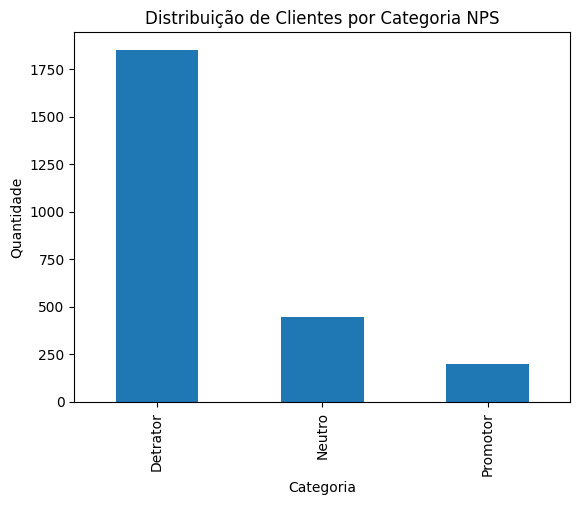

In [3]:
def categorize_nps(score):
    if score <= 6:
        return "Detrator"
    elif score <= 8:
        return "Neutro"
    else:
        return "Promotor"

df["nps_category"] = df["nps_score"].apply(categorize_nps)


df["nps_category"].value_counts().plot(kind="bar")
plt.title("Distribuição de Clientes por Categoria NPS")
plt.xlabel("Categoria")
plt.ylabel("Quantidade")
plt.show()

In [4]:
print("Shape da base:", df.shape)
print("\nColunas:")
print(df.columns.tolist())

print("\nResumo estatístico:")
print(df.describe())

Shape da base: (2500, 20)

Colunas:
['customer_id', 'customer_age', 'customer_region', 'customer_tenure_months', 'order_id', 'order_value', 'items_quantity', 'discount_value', 'payment_installments', 'delivery_time_days', 'delivery_delay_days', 'freight_value', 'delivery_attempts', 'customer_service_contacts', 'resolution_time_days', 'nps_score', 'repeat_purchase_30d', 'complaints_count', 'csat_internal_score', 'nps_category']

Resumo estatístico:
       customer_id  customer_age  customer_tenure_months     order_id  \
count   2500.00000   2500.000000             2500.000000   2500.00000   
mean    1250.50000     43.396000               61.322400  51250.50000   
std      721.83216     14.888487               34.478729    721.83216   
min        1.00000     18.000000                1.000000  50001.00000   
25%      625.75000     31.000000               31.000000  50625.75000   
50%     1250.50000     43.000000               62.000000  51250.50000   
75%     1875.25000     56.000000     


Correlação das variáveis com nps_score:
nps_score                    1.000000
delivery_delay_days         -0.597260
repeat_purchase_30d          0.570324
csat_internal_score          0.563952
complaints_count            -0.496800
customer_service_contacts   -0.350845
resolution_time_days        -0.191392
freight_value               -0.041087
order_value                  0.036990
delivery_attempts            0.027680
discount_value               0.025104
payment_installments         0.023718
order_id                     0.015162
customer_id                  0.015162
items_quantity               0.011468
customer_age                -0.009936
customer_tenure_months      -0.009711
delivery_time_days           0.000925
Name: nps_score, dtype: float64


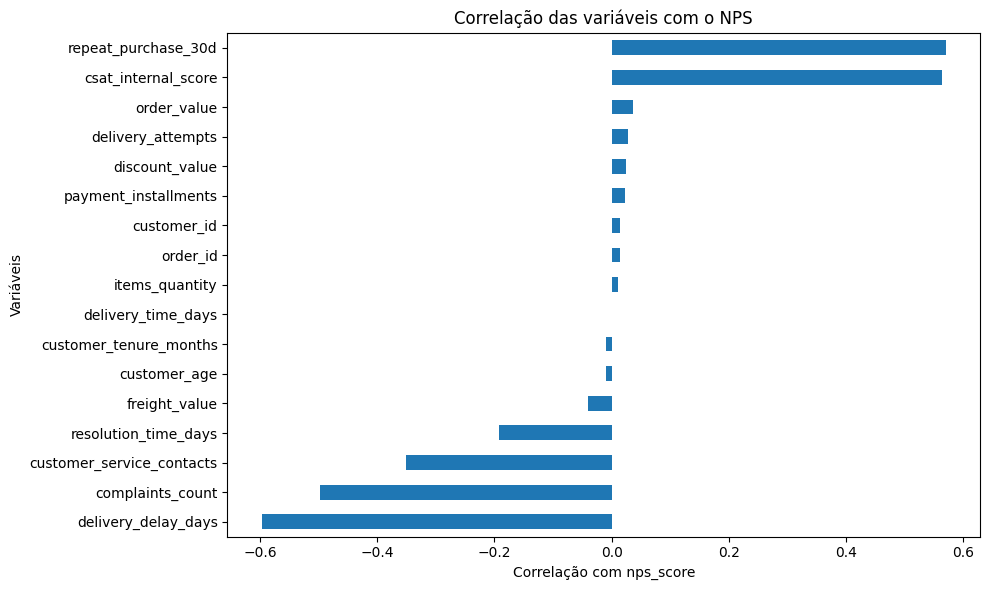

In [5]:
numeric_cols = df.select_dtypes(include="number").columns

corr_with_nps = (
    df[numeric_cols]
    .corr()["nps_score"]
    .sort_values(key=abs, ascending=False)
)

print("\nCorrelação das variáveis com nps_score:")
print(corr_with_nps)

# Gráfico das correlações
corr_plot = corr_with_nps.drop("nps_score").sort_values()
plt.figure(figsize=(10, 6))
corr_plot.plot(kind="barh")
plt.title("Correlação das variáveis com o NPS")
plt.xlabel("Correlação com nps_score")
plt.ylabel("Variáveis")
plt.tight_layout()
plt.show()


Média das principais métricas por categoria de NPS:
              delivery_delay_days  complaints_count  \
nps_category                                          
Detrator                 2.534306          4.622907   
Neutro                   1.395089          2.986607   
Promotor                 0.756219          2.393035   

              customer_service_contacts  resolution_time_days  
nps_category                                                   
Detrator                       1.694219              5.793625  
Neutro                         1.129464              4.832589  
Promotor                       0.781095              4.104478  


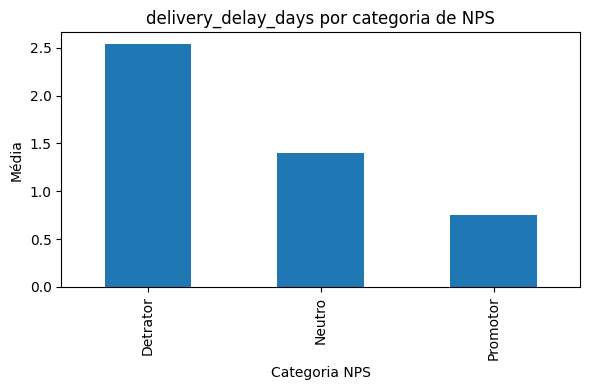

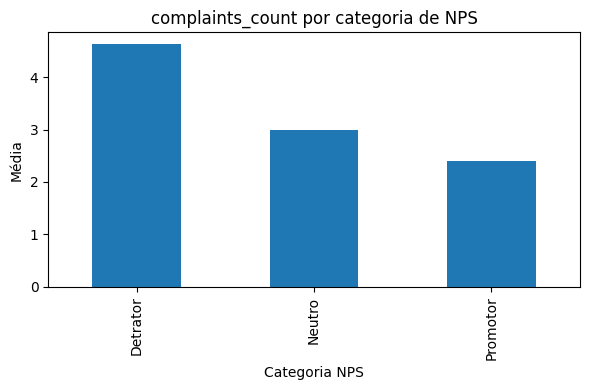

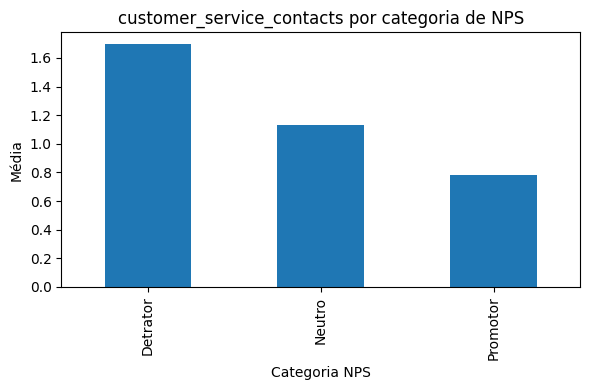

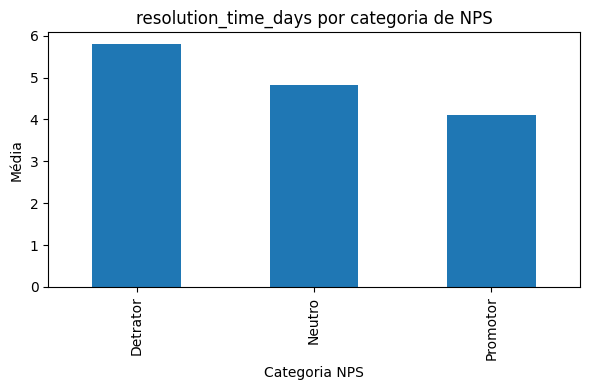

In [6]:
key_metrics = [
    "delivery_delay_days",
    "complaints_count",
    "customer_service_contacts",
    "resolution_time_days"
]

group_means = df.groupby("nps_category")[key_metrics].mean()
print("\nMédia das principais métricas por categoria de NPS:")
print(group_means)

for col in key_metrics:
    plt.figure(figsize=(6, 4))
    group_means[col].reindex(["Detrator", "Neutro", "Promotor"]).plot(kind="bar")
    plt.title(f"{col} por categoria de NPS")
    plt.ylabel("Média")
    plt.xlabel("Categoria NPS")
    plt.tight_layout()
    plt.show()


NPS médio por faixa de atraso:
delay_range
Sem atraso    6.856679
1-2 dias      5.051308
3-5 dias      2.893633
6-10 dias     0.811765
10+ dias           NaN
Name: nps_score, dtype: float64


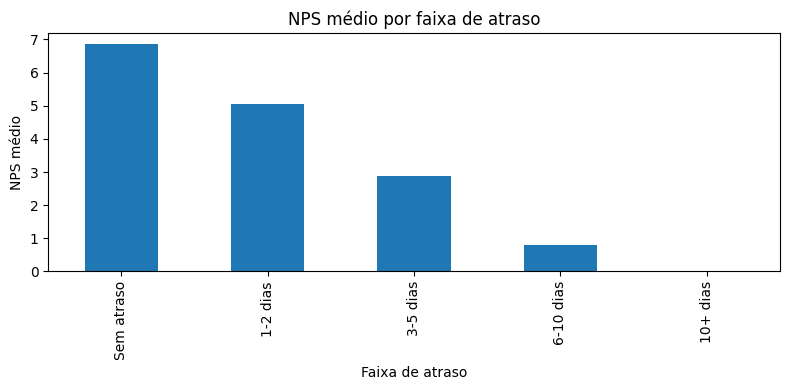


NPS médio por faixa de contatos com atendimento:
contact_range
0      5.543502
1      4.657108
2      4.116406
3-4    3.039910
5+     1.929545
Name: nps_score, dtype: float64


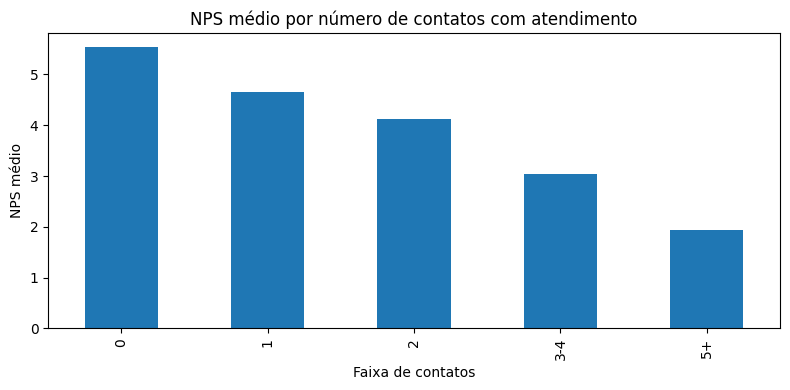

In [7]:
delay_bins = [-1, 0, 2, 5, 10, 100]
delay_labels = ["Sem atraso", "1-2 dias", "3-5 dias", "6-10 dias", "10+ dias"]
df["delay_range"] = pd.cut(df["delivery_delay_days"], bins=delay_bins, labels=delay_labels)

delay_nps = df.groupby("delay_range")["nps_score"].mean()
print("\nNPS médio por faixa de atraso:")
print(delay_nps)

plt.figure(figsize=(8, 4))
delay_nps.plot(kind="bar")
plt.title("NPS médio por faixa de atraso")
plt.ylabel("NPS médio")
plt.xlabel("Faixa de atraso")
plt.tight_layout()
plt.show()

# Exemplo com quantidade de contatos
contact_bins = [-1, 0, 1, 2, 4, 100]
contact_labels = ["0", "1", "2", "3-4", "5+"]
df["contact_range"] = pd.cut(df["customer_service_contacts"], bins=contact_bins, labels=contact_labels)

contact_nps = df.groupby("contact_range")["nps_score"].mean()
print("\nNPS médio por faixa de contatos com atendimento:")
print(contact_nps)

plt.figure(figsize=(8, 4))
contact_nps.plot(kind="bar")
plt.title("NPS médio por número de contatos com atendimento")
plt.ylabel("NPS médio")
plt.xlabel("Faixa de contatos")
plt.tight_layout()
plt.show()

##MODELO

In [11]:
# Exc luindo:
# - nps_score: target
# - customer_id / order_id: identificadores
# - repeat_purchase_30d: consequência futura
# - csat_internal_score: métrica de satisfação muito próxima do alvo

exclude_cols = [
    "nps_score",
    "customer_id",
    "order_id",
    "repeat_purchase_30d",
    "csat_internal_score",
    "nps_category",
    "delay_range",
    "contact_range"
]

X = df.drop(columns=exclude_cols)
y = df["nps_score"]

categorical_cols = X.select_dtypes(include="object").columns.tolist()
numerical_cols = [col for col in X.columns if col not in categorical_cols]

preprocessor = ColumnTransformer([
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
    ("num", "passthrough", numerical_cols)
])

model = RandomForestRegressor(
    n_estimators=300,
    random_state=42
)

pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", model)
])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

pipeline.fit(X_train, y_train)
pred = pipeline.predict(X_test)

print("\nR² do modelo:", r2_score(y_test, pred))


KeyError: "['nps_category', 'delay_range', 'contact_range'] not found in axis"